In [1]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
import torch.nn.functional as F

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[INFO] Using device:", device)

NUM_CLASSES = 11
IMG_SIZE = 224
BATCH_SIZE = 2
EPOCHS = 15
LR = 1e-4

[INFO] Using device: cuda


In [3]:
COLOR_TO_CLASS = {
    (0, 0, 0): 0,
    (27, 71, 151): 1,
    (111, 48, 253): 2,
    (137, 126, 126): 3,
    (201, 19, 223): 4,
    (238, 171, 171): 5,
    (254, 233, 3): 6,
    (255, 0, 29): 7,
    (255, 159, 0): 8,
    (255, 160, 1): 9,
    (255, 235, 0): 10
}

In [4]:
class FootballDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.pairs = []

        all_images = set(os.listdir(img_dir))
        for mask_name in os.listdir(mask_dir):
            if not mask_name.endswith("___fuse.png"):
                continue
            image_name = mask_name.replace("___fuse.png", "")
            if image_name in all_images:
                img_path = os.path.join(img_dir, image_name)
                mask_path = os.path.join(mask_dir, mask_name)
                self.pairs.append((img_path, mask_path))
        self.pairs = sorted(self.pairs)
        print(f"[DATASET INIT] valid pairs found: {len(self.pairs)}")

    def __len__(self):
        return len(self.pairs)

    def rgb_to_mask(self, mask):
        h, w, _ = mask.shape
        out = np.zeros((h, w), dtype=np.uint8)
        for color, cls in COLOR_TO_CLASS.items():
            out[np.all(mask == np.array(color), axis=-1)] = cls
        return torch.tensor(out, dtype=torch.long)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path)
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
        mask = self.rgb_to_mask(mask)

        if self.transform:
            img = self.transform(img)

        mask = F.interpolate(
            mask.unsqueeze(0).unsqueeze(0).float(),
            size=(IMG_SIZE, IMG_SIZE),
            mode="nearest"
        ).squeeze().long()

        return img, mask

In [5]:
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])


dataset = FootballDataset("/kaggle/input/datasets/fatemehsariri/data-set/normal_only", "/kaggle/input/datasets/fatemehsariri/data-set/semantic_only", transform)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

print("[INFO] Train size:", train_size, "Val size:", val_size)

[DATASET INIT] valid pairs found: 99
[INFO] Train size: 79 Val size: 20


In [6]:
vgg = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1)

class FCN32s(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = vgg.features

        for p in self.features.parameters():
            p.requires_grad = False

        self.conv6 = nn.Conv2d(512, 4096, 7)
        self.relu6 = nn.ReLU(inplace=True)
        self.drop6 = nn.Dropout2d()

        self.conv7 = nn.Conv2d(4096, 4096, 1)
        self.relu7 = nn.ReLU(inplace=True)
        self.drop7 = nn.Dropout2d()

        self.score = nn.Conv2d(4096, num_classes, 1)

        self.upscore = nn.ConvTranspose2d(
            num_classes,
            num_classes,
            kernel_size=64,
            stride=32,
            padding=16
        )

    def forward(self, x):
        x = self.features(x)

        x = self.relu6(self.conv6(x))
        x = self.drop6(x)

        x = self.relu7(self.conv7(x))
        x = self.drop7(x)

        x = self.score(x)
        x = self.upscore(x)

        x = F.interpolate(x, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)

        return x


model = FCN32s(NUM_CLASSES).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

print("[INFO] Model ready")

[INFO] Model ready


In [7]:
def train():
    best_loss = 1e9

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0

        for imgs, masks in train_loader:
            imgs = imgs.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, masks)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)

        print(f"[TRAIN] epoch {epoch+1}/{EPOCHS} loss: {avg_loss:.4f}")

        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.state_dict(), "best_model.pth")
            print("[SAVE] model saved")

In [8]:
def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img = img * std + mean
    return img


def evaluate():
    model.eval()

    imgs, masks = next(iter(val_loader))

    with torch.no_grad():
        preds = model(imgs.to(device))
        preds = torch.argmax(preds, dim=1).cpu()

    for i in range(min(2, imgs.size(0))):
        plt.figure(figsize=(10,3))

        plt.subplot(1,3,1)

        img_show = denormalize(imgs[i]).cpu()
        img_show = img_show.permute(1,2,0).numpy()
        img_show = np.clip(img_show, 0, 1)

        plt.imshow(img_show)
        plt.title("Image")

        plt.subplot(1,3,2)
        plt.imshow(masks[i])
        plt.title("GT")

        plt.subplot(1,3,3)
        plt.imshow(preds[i])
        plt.title("Pred")

        plt.show()

[TRAIN] epoch 1/15 loss: 1.8187
[SAVE] model saved
[TRAIN] epoch 2/15 loss: 1.2240
[SAVE] model saved
[TRAIN] epoch 3/15 loss: 1.1711
[SAVE] model saved
[TRAIN] epoch 4/15 loss: 1.1166
[SAVE] model saved
[TRAIN] epoch 5/15 loss: 0.8972
[SAVE] model saved
[TRAIN] epoch 6/15 loss: 0.7735
[SAVE] model saved
[TRAIN] epoch 7/15 loss: 0.7221
[SAVE] model saved
[TRAIN] epoch 8/15 loss: 0.6958
[SAVE] model saved
[TRAIN] epoch 9/15 loss: 0.6467
[SAVE] model saved
[TRAIN] epoch 10/15 loss: 0.6176
[SAVE] model saved
[TRAIN] epoch 11/15 loss: 0.5897
[SAVE] model saved
[TRAIN] epoch 12/15 loss: 0.5628
[SAVE] model saved
[TRAIN] epoch 13/15 loss: 0.5383
[SAVE] model saved
[TRAIN] epoch 14/15 loss: 0.5043
[SAVE] model saved
[TRAIN] epoch 15/15 loss: 0.4872
[SAVE] model saved


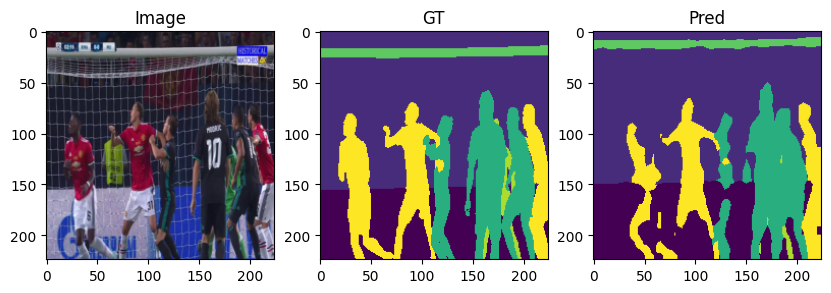

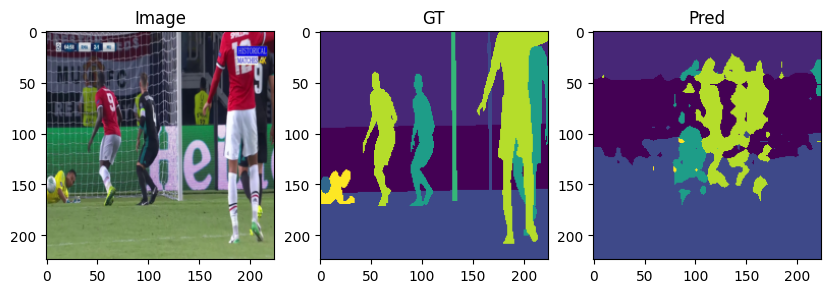

In [9]:
train()
evaluate()